# MLP Medium orientada a RMSE en dólares


In [14]:
import os, random, time
from itertools import product
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import joblib

SEED=42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed()
torch.backends.cudnn.deterministic=True
torch.backends.cudnn.benchmark=False
device="cuda" if torch.cuda.is_available() else "cpu"
print("Device:",device)

X_train=np.load("data/X_train_processed.npy")
X_val=np.load("data/X_val_processed.npy")
y_train=np.load("data/y_train_scaled.npy")
y_val=np.load("data/y_val_scaled.npy")
y_train_usd=np.load("data/y_train_usd.npy")
y_val_usd=np.load("data/y_val_usd.npy")
target_scaler=joblib.load("models/target_scaler_v2.joblib")
Y_MEAN=target_scaler["mean"]; Y_STD=target_scaler["std"]
print(X_train.shape, X_val.shape, f"target mean=${Y_MEAN:,.0f}, std=${Y_STD:,.0f}")

Device: cpu
(934, 278) (234, 278) target mean=$181,637, std=$78,015


In [15]:
class MLP(nn.Module):
    def __init__(self,input_dim,hidden,dropout=0.0):
        super().__init__()
        layers=[]; prev=input_dim
        for h in hidden:
            layers += [nn.Linear(prev,h), nn.ReLU()]
            if dropout>0: layers.append(nn.Dropout(dropout))
            prev=h
        layers.append(nn.Linear(prev,1))
        self.net=nn.Sequential(*layers)
    def forward(self,x): return self.net(x).squeeze(1)

ARCH_NAME = "medium"
HIDDEN = [128, 64]
m=MLP(X_train.shape[1],HIDDEN)
print("Arquitectura fija:", ARCH_NAME, HIDDEN)
print("Parámetros:", sum(p.numel() for p in m.parameters()))


Arquitectura fija: medium [128, 64]
Parámetros: 44033


In [16]:
def scaled_to_usd(a): return np.asarray(a)*Y_STD+Y_MEAN
def rmse_usd(y_true_usd,pred_scaled):
    pred_usd=scaled_to_usd(pred_scaled)
    return float(np.sqrt(np.mean((pred_usd-y_true_usd)**2)))

def train_model(hidden, hp, seed=SEED, verbose=False):
    set_seed(seed)
    model=MLP(X_train.shape[1],hidden,hp["dropout"]).to(device)
    opt=torch.optim.AdamW(model.parameters(),lr=hp["lr"],weight_decay=hp["weight_decay"])
    loss_fn=nn.MSELoss()
    Xtr=torch.tensor(X_train,dtype=torch.float32); ytr=torch.tensor(y_train,dtype=torch.float32)
    Xva=torch.tensor(X_val,dtype=torch.float32).to(device)
    loader=DataLoader(TensorDataset(Xtr,ytr),batch_size=hp["batch_size"],shuffle=True,
                      generator=torch.Generator().manual_seed(seed))
    best_rmse=float("inf"); best_state=None; best_epoch=-1; wait=0
    hist={"train_loss":[],"val_rmse_usd":[]}
    for epoch in range(hp["max_epochs"]):
        model.train(); losses=[]
        for xb,yb in loader:
            xb,yb=xb.to(device),yb.to(device)
            opt.zero_grad(); pred=model(xb); loss=loss_fn(pred,yb); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),5.0)
            opt.step(); losses.append(loss.item())
        model.eval()
        with torch.no_grad(): vp=model(Xva).cpu().numpy()
        vr=rmse_usd(y_val_usd,vp)
        hist["train_loss"].append(float(np.mean(losses))); hist["val_rmse_usd"].append(vr)
        if vr < best_rmse-1e-6:
            best_rmse=vr; best_epoch=epoch; wait=0
            best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else: wait+=1
        if verbose and epoch%25==0: print(f"epoch {epoch:3d} | RMSE=${vr:,.2f}")
        if wait>=hp["patience"]: break
    model.load_state_dict(best_state); model.to(device); model.eval()
    return model,hist,best_rmse,best_epoch

## Grid de hiperparámetros 


In [17]:
grid={
    "lr":[3e-4,1e-3,2e-3],
    "dropout":[0.0,0.1,0.2],
    "weight_decay":[0.0,1e-4,1e-3],
}
rows=[]; best_model=None; best_history=None; global_best=float("inf"); best_hp=None; best_epoch=None
for i,(lr,drop,wd) in enumerate(product(grid["lr"],grid["dropout"],grid["weight_decay"]),1):
    hp={"lr":lr,"dropout":drop,"weight_decay":wd,"batch_size":32,"max_epochs":600,"patience":50}
    m,h,r,e=train_model(HIDDEN,hp)
    rows.append({**hp,"RMSE_USD":r,"best_epoch":e})
    print(f"[{i:02d}/27] lr={lr:.0e} drop={drop:.1f} wd={wd:.0e} -> ${r:,.2f}")
    if r<global_best:
        global_best=r; best_model=m; best_history=h; best_hp=hp.copy(); best_epoch=e
results_df=pd.DataFrame(rows).sort_values("RMSE_USD").reset_index(drop=True)
results_df


[01/27] lr=3e-04 drop=0.0 wd=0e+00 -> $27,170.23
[02/27] lr=3e-04 drop=0.0 wd=1e-04 -> $27,136.04
[03/27] lr=3e-04 drop=0.0 wd=1e-03 -> $27,132.48
[04/27] lr=3e-04 drop=0.1 wd=0e+00 -> $26,367.31
[05/27] lr=3e-04 drop=0.1 wd=1e-04 -> $26,402.87
[06/27] lr=3e-04 drop=0.1 wd=1e-03 -> $26,274.49
[07/27] lr=3e-04 drop=0.2 wd=0e+00 -> $27,243.41
[08/27] lr=3e-04 drop=0.2 wd=1e-04 -> $27,214.41
[09/27] lr=3e-04 drop=0.2 wd=1e-03 -> $27,201.78
[10/27] lr=1e-03 drop=0.0 wd=0e+00 -> $26,330.43
[11/27] lr=1e-03 drop=0.0 wd=1e-04 -> $26,299.32
[12/27] lr=1e-03 drop=0.0 wd=1e-03 -> $26,383.27
[13/27] lr=1e-03 drop=0.1 wd=0e+00 -> $25,958.87
[14/27] lr=1e-03 drop=0.1 wd=1e-04 -> $26,184.93
[15/27] lr=1e-03 drop=0.1 wd=1e-03 -> $25,913.65
[16/27] lr=1e-03 drop=0.2 wd=0e+00 -> $26,459.70
[17/27] lr=1e-03 drop=0.2 wd=1e-04 -> $25,982.32
[18/27] lr=1e-03 drop=0.2 wd=1e-03 -> $26,414.26
[19/27] lr=2e-03 drop=0.0 wd=0e+00 -> $25,341.09
[20/27] lr=2e-03 drop=0.0 wd=1e-04 -> $26,904.06
[21/27] lr=2e-03 dro

,lr,dropout,weight_decay,batch_size,max_epochs,patience,RMSE_USD,best_epoch
0,0.0020,0.2,0.0001,32,600,50,23768.275391,33
1,0.0020,0.2,0.0000,32,600,50,24123.939453,45
2,0.0020,0.1,0.0001,32,600,50,24638.437500,72
3,0.0020,0.1,0.0010,32,600,50,24654.048828,10
4,0.0020,0.2,0.0010,32,600,50,25045.257812,20
5,0.0020,0.1,0.0000,32,600,50,25104.820312,20
6,0.0020,0.0,0.0000,32,600,50,25341.093750,33
7,0.0020,0.0,0.0010,32,600,50,25756.703125,17
8,0.0010,0.1,0.0010,32,600,50,25913.654297,14
9,0.0010,0.1,0.0000,32,600,50,25958.873047,14


## Resultado y comparación con Ridge


In [18]:
baseline=pd.read_csv("reports/baseline_v2.csv")
baseline_rmse=float(baseline.iloc[0]["RMSE_USD"])
print("Arquitectura:",ARCH_NAME,HIDDEN)
print("Hiperparámetros:",best_hp)
print(f"RMSE MLP Medium: ${global_best:,.2f}")
print(f"RMSE Ridge:      ${baseline_rmse:,.2f}")
print(f"Diferencia:      ${global_best-baseline_rmse:,.2f}")
print("Objetivo < $30,000:", "ALCANZADO" if global_best<30000 else "AÚN NO")


Arquitectura: medium [128, 64]
Hiperparámetros: {'lr': 0.002, 'dropout': 0.2, 'weight_decay': 0.0001, 'batch_size': 32, 'max_epochs': 600, 'patience': 50}
RMSE MLP Medium: $23,768.28
RMSE Ridge:      $31,360.03
Diferencia:      $-7,591.75
Objetivo < $30,000: ALCANZADO


## Evaluación Train vs. Validación


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def predict_usd(model, X):
    model.eval()
    with torch.no_grad():
        ps=model(torch.tensor(X,dtype=torch.float32).to(device)).cpu().numpy()
    return scaled_to_usd(ps)

def metrics(y_true,pred):
    return {
        "RMSE_USD": float(np.sqrt(mean_squared_error(y_true,pred))),
        "MAE_USD": float(mean_absolute_error(y_true,pred)),
        "R2": float(r2_score(y_true,pred)),
    }

pred_train_usd=predict_usd(best_model,X_train)
pred_val_usd=predict_usd(best_model,X_val)
train_metrics=metrics(y_train_usd,pred_train_usd)
val_metrics=metrics(y_val_usd,pred_val_usd)

metrics_df=pd.DataFrame([
    {"conjunto":"Train",**train_metrics},
    {"conjunto":"Validación",**val_metrics},
])
display(metrics_df)

gap=val_metrics["RMSE_USD"]-train_metrics["RMSE_USD"]
ratio=val_metrics["RMSE_USD"]/train_metrics["RMSE_USD"]
print(f"RMSE Medium Train:      ${train_metrics['RMSE_USD']:,.2f}")
print(f"RMSE Medium Validación: ${val_metrics['RMSE_USD']:,.2f}")
print(f"Gap Val - Train:        ${gap:,.2f}")
print(f"Ratio Val/Train:         {ratio:.2f}x")


,conjunto,RMSE_USD,MAE_USD,R2
0,Train,13241.873583,8633.360352,0.971190
1,Validación,23768.274653,15621.987305,0.896862


RMSE Medium Train:      $13,241.87
RMSE Medium Validación: $23,768.27
Gap Val - Train:        $10,526.40
Ratio Val/Train:         1.79x


## Gráficas y análisis de errores


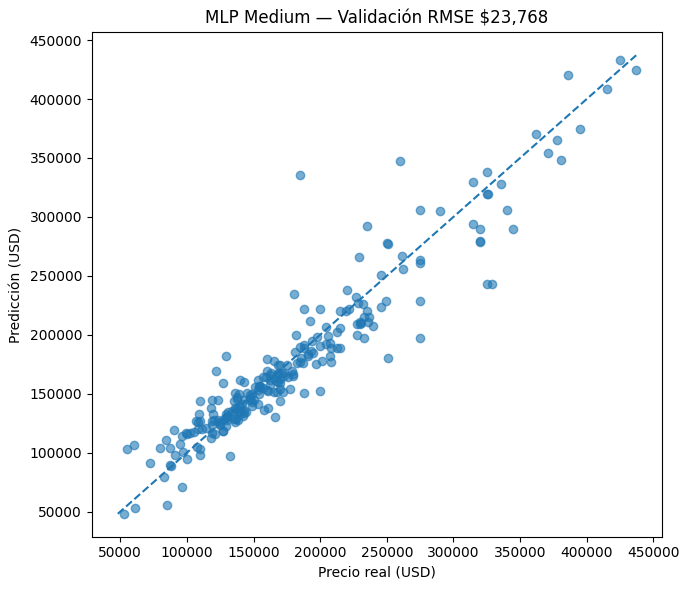

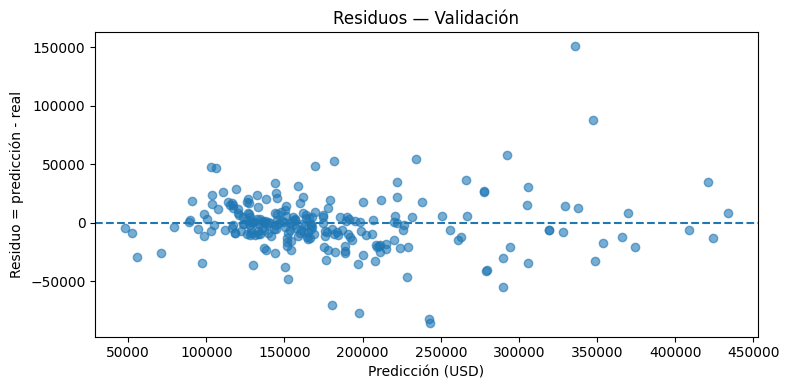

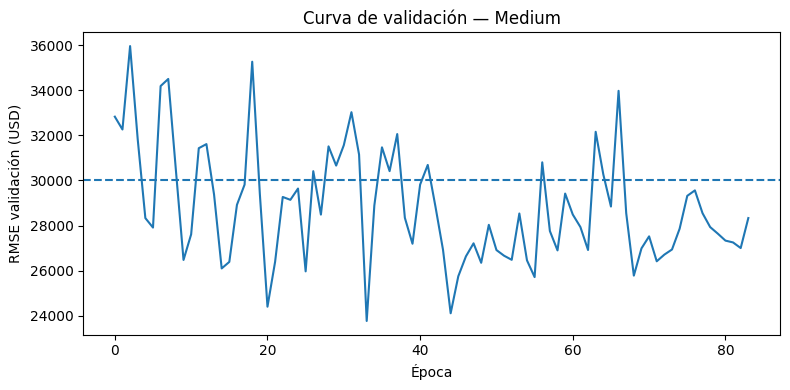

,real_usd,pred_usd,error,error_abs,error_pct
0,184750.0,335637.375000,150887.375000,150887.375000,81.671104
1,260000.0,347567.687500,87567.687500,87567.687500,33.679878
2,328900.0,243373.796875,-85526.203125,85526.203125,26.003710
3,325000.0,242686.562500,-82313.437500,82313.437500,25.327211
4,274970.0,197504.843750,-77465.156250,77465.156250,28.172222
5,250580.0,180555.921875,-70024.078125,70024.078125,27.944799
6,235000.0,292480.781250,57480.781250,57480.781250,24.459908
7,345000.0,290059.750000,-54940.250000,54940.250000,15.924710
8,180000.0,234280.718750,54280.718750,54280.718750,30.155954
9,129000.0,181893.390625,52893.390625,52893.390625,41.002628


In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(y_val_usd,pred_val_usd,alpha=.6)
lo=min(y_val_usd.min(),pred_val_usd.min()); hi=max(y_val_usd.max(),pred_val_usd.max())
plt.plot([lo,hi],[lo,hi],'--')
plt.xlabel("Precio real (USD)"); plt.ylabel("Predicción (USD)")
plt.title(f"MLP Medium — Validación RMSE ${val_metrics['RMSE_USD']:,.0f}")
plt.tight_layout(); plt.show()

residuals=pred_val_usd-y_val_usd
plt.figure(figsize=(8,4))
plt.scatter(pred_val_usd,residuals,alpha=.6)
plt.axhline(0,linestyle='--')
plt.xlabel("Predicción (USD)"); plt.ylabel("Residuo = predicción - real")
plt.title("Residuos — Validación")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
plt.plot(best_history["val_rmse_usd"]); plt.axhline(30000,linestyle='--')
plt.xlabel("Época"); plt.ylabel("RMSE validación (USD)"); plt.title("Curva de validación — Medium")
plt.tight_layout(); plt.show()

errors_df=pd.DataFrame({
    "real_usd":y_val_usd,
    "pred_usd":pred_val_usd,
    "error":residuals,
    "error_abs":np.abs(residuals),
    "error_pct":np.abs(residuals)/np.maximum(np.abs(y_val_usd),1)*100,
}).sort_values("error_abs",ascending=False).reset_index(drop=True)
display(errors_df.head(10))


## Guardar modelo 


In [21]:
os.makedirs("models",exist_ok=True); os.makedirs("reports",exist_ok=True)
torch.save({
    "model_state_dict":best_model.state_dict(),
    "architecture_name":ARCH_NAME,
    "hidden_layers":HIDDEN,
    "hyperparams":best_hp,
    "best_epoch":best_epoch,
    "val_rmse_usd":global_best,
    "train_rmse_usd":train_metrics["RMSE_USD"],
    "target_mean":Y_MEAN,
    "target_std":Y_STD,
    "seed":SEED,
},"models/best_mlp_medium_v2.pt")
results_df.to_csv("reports/mlp_medium_grid_v2.csv",index=False)
metrics_df.to_csv("reports/mlp_medium_train_val_metrics.csv",index=False)
errors_df.to_csv("reports/mlp_medium_val_errors.csv",index=False)
print("Guardado: models/best_mlp_medium_v2.pt")
print("RMSE validación Medium:",f"${global_best:,.2f}")


Guardado: models/best_mlp_medium_v2.pt
RMSE validación Medium: $23,768.28
